# Rural Fire Dataset – Explainable Artificial Intelligence (XAI) Project

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022), Nuno Moreira (202104873) and Pedro Silva (202205150).

## Table of Contents

1. [Introduction](#introduction)  

2. [Pre-Modelling](#pre-modelling)  
   - 2.1. [Dataset Description](#dataset-description)  
   - 2.2. [Data Preprocessing](#data-preprocessing)  
     - 2.2.1. [Type Standardization and NA Handling](#221-type-standardization-and-na-handling)  
     - 2.2.2. [Timestamp Reconstruction from Excel Serials](#222-timestamp-reconstruction-from-excel-serials)  
     - 2.2.3. [Fire Duration Calculation and Validation](#223-fire-duration-calculation-and-validation)  
     - 2.2.4. [Area Consistency and Completeness Filter](#224-area-consistency-and-completeness-filter)  
     - 2.2.5. [Temporal Feature Extraction](#225-temporal-feature-extraction)  
     - 2.2.6. [Missing Data Summary](#226-missing-data-summary)  
     - 2.2.7. [Numeric Consistency](#227-numeric-consistency)  
     - 2.2.8. [Area Consistency](#228-area-consistency)  
     - 2.2.9. [Inspection of Inconsistent Area Record](#229-inspection-of-inconsistent-area-record)  
     - 2.2.10. [Temporal Coherence Validation](#2210-temporal-coherence-validation)  
     - 2.2.11. [Administrative Division Consistency](#2211-administrative-division-consistency)  
     - 2.2.12. [Categorical Variable Identification](#2212-categorical-variable-identification)  
     - 2.2.13. [Conversion to Categorical Data Type](#2213-conversion-to-categorical-data-type)  
   - 2.3. [Data Understanding and Descriptive Analysis](#data-understanding-and-descriptive-analysis)
     - 2.3.1. [Temporal Analysis](#231-temporal-analysis)
     - 2.3.2. [Monthly Patterns](#232-monthly-patterns)
     - 2.3.3. [Duration Distribution](#233-duration-distribution)
     - 2.3.4. [Spatial Analysis](#234-spatial-analysis)
     - 2.3.5. [Spatial Distribution of Fire Incidents by District (1980–2005)](#235-spatial-distribution-of-fire-incidents-by-district-19802005)
     - 2.3.6. [Comparison Between Fire Frequency and Total Burned Area by District (1980–2005)](#236-comparison-between-fire-frequency-and-total-burned-area-by-district-19802005)
     - 2.3.7. [Land Cover Composition](#237-land-cover-composition)
     - 2.3.8. [Fire Size Categories](#238-fire-size-categories)
     - 2.3.9. [Fire Causes](#239-fire-causes)
     - 2.3.10. [Distribution of Fire Causes in Portugal (1980–2005, Excluding “Unknown”)](#2310-distribution-of-fire-causes-in-portugal-19802005-excluding-unknown)
     - 2.3.11. [Correlation Matrix](#2311-correlation-matrix)
     - 2.3.12. [Derived Ratios](#2312-derived-ratios)
     - 2.3.13. [Suspicious Records Visualization](#2313-suspicious-records-visualization)
              

3. [In-Modelling](#in-modelling)  
   - 3.1. [Model Training](#model-training)  

4. [Post-Modelling](#post-modelling)  
   - 4.1. [Explainability Techniques](#explainability-techniques)  
   - 4.2. [Feature Importance](#feature-importance)  
   - 4.3. [SHAP (SHapley Additive exPlanations)](#shap-shapley-additive-explanations)  
   - 4.4. [LIME (Local Interpretable Model-agnostic Explanations)](#lime-local-interpretable-model-agnostic-explanations)  

5. [Results and Visualization](#results-and-visualization)  

6. [Conclusions and Future Work](#conclusions-and-future-work)


## 1. Introduction

### What is Explainable Artificial Intelligence (XAI)?

Explainable Artificial Intelligence (XAI) is a research field focused on making machine learning (ML) systems **transparent and understandable to humans**.  
Rather than producing only predictions, XAI seeks to explain **how** and **why** those predictions are made, helping humans trust and validate AI systems.

According to Rita P. Ribeiro (FCUP, 2024), XAI comprises **techniques applied before, during, or after** model training:
- **Pre-modelling**: understanding the data (visualization, dimensionality reduction, prototypes).  
- **In-modelling**: using inherently interpretable models (linear, rule-based, or transparent architectures).  
- **Post-modelling (post-hoc)**: explaining black-box models through simplification, feature importance, or example-based reasoning (e.g. SHAP, LIME, counterfactuals).

In this context, *interpretable models* are those that are “understandable as-is” (e.g., linear regression), while *explainable models* may require external tools to make their reasoning clear (Arrieta et al., 2020).  
XAI thus bridges human understanding with model complexity, ensuring **trust, accountability, and fairness** in AI-driven decisions.

### Why XAI Matters

High-performance models such as neural networks or ensembles are often *black boxes*.  
Without explainability, their use in critical areas (e.g., healthcare, environmental prediction, or finance) becomes risky.  
XAI supports:
- **Transparency and justification** of predictions.  
- **Detection of bias** and mitigation of unfair decisions.  
- **Model debugging and improvement** by practitioners.  
- **Trust** from stakeholders and end-users.  

### Project Motivation

This notebook is developed within the *Advanced Topics on Machine Learning* (M.IA009) course and follows the official project structure proposed by Professor Rita P. Ribeiro (2025/2026).  
The main objective is to **explore the interpretability and insights provided by Explainable Artificial Intelligence (XAI)** techniques in a **supervised learning context using tabular data**.

Specifically, this case study focuses on the **Rural Fires dataset (DS3)**, aiming to build predictive models that estimate fire occurrence or intensity. 
The project adopts an end-to-end perspective, covering **pre-modelling, in-modelling, and post-modelling** XAI phases:

- **Pre-Modelling**: Understanding the dataset through exploratory visualization and correlation analysis to identify relevant variables before training.  
- **In-Modelling**: Training an interpretable (glass-box) model and assessing the intrinsic explainability of its structure.  
- **Post-Modelling**: Applying post-hoc explanation techniques to black-box models, such as:
  - Simplification-based (e.g., surrogate models);
  - Feature-based (e.g., SHAP, LIME);
  - Example-based (e.g., counterfactuals or anchors).

The project follows the evaluation and deliverable criteria defined in the course guide, including:
- **Task 1** – Pre-modelling explanations;  
- **Task 2** – In-modelling explanations;  
- **Task 3** – Post-modelling explanations (simplification, feature-based, and example-based);  
- **Task 4** – Evaluation of explanation quality using at least one *functionally grounded metric* (e.g., fidelity, stability, completeness).

Through this study, we aim to:
- Train and compare interpretable and non-interpretable models for fire prediction;  
- Apply multiple XAI techniques to understand feature relevance both globally (model-level) and locally (instance-level);  
- Discuss the **consistency**, **fidelity**, and **usefulness** of different explanations;  
- Derive interpretable and actionable insights for fire prevention and environmental decision-making.

Ultimately, this project combines **data-driven modeling** with **explainability analysis**, providing a structured workflow aligned with the course objectives:
> *Data understanding → Model learning → Explanation → Evaluation → Knowledge extraction.*


### 2. Pre-Modelling 
[[go back to the top]](#table-of-contents)

This section focuses on understanding the dataset before model training through exploratory data analysis and preprocessing to identify relevant patterns and potential issues.


#### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import unicodedata
import re

#### 2.1. Dataset Description 
[[go back to the topic]](#pre-modelling)


This subsection presents the Rural Fires dataset, a tabular collection describing individual fire events with geographic, temporal, and land-use attributes.
It includes information such as district, county, parish, ownership and land-cover areas (forest, shrubland, agriculture), ignition and extinction timestamps, intervention times, and categorical variables like fire_type and cause_code.

In this stage, we also validate the raw ingest and prepare the data for analysis.
The file arrives as a tab-delimited text containing heterogeneous types (strings, nullable integers, and floats) and special missing-value tokens (e.g., -999.9, UNKNOWN, 99:99).
We imported the raw text file into a structured DataFrame and exported it as a clean CSV, ensuring the dataset is properly formatted, consistent, and ready for normalization and analysis in subsequent stages.

This step provides a comprehensive overview of the dataset’s structure, quality, and semantics, forming the basis for reliable preprocessing and interpretable modelling.

In [5]:
txt_path = "data/PRFD_1980_2005_17Nov11.txt"
cols = ["district_id","district","county","parish",
        "shrub_pub","shrub_priv","shrub_total",
        "forest_pub","forest_priv","forest_total",
        "area_total","area_agri","fire_type","cause_code",
        "ign_date_serial","ign_time_frac","ign_hour","ign_min",
        "ext_date_serial","ext_time_frac","ext_hour","ext_min",
        "duration_frac","flag1","flag2","flag3","flag4",
        "first_interv_time","weekday"]

df = pd.read_csv(
    txt_path, sep="\t", header=None, names=cols,
    na_values=["-999.9","UNKNOWN","99:99"],
    low_memory=False     
)                         

df.to_csv("data/FireDataset.csv", index=False, encoding="utf-8", na_rep="")

#### Basic structure
Here we quickly verified the shape, first rows, and column names of the imported dataset. This step ensures that the file was read correctly, that all 29 expected columns are present, and that the data aligns properly with the predefined schema before moving forward with cleaning or transformation.


In [6]:
print("Shape:", df.shape)
print(df.head(2))
print(df.columns.tolist())

Shape: (453577, 29)
   district_id  district        county        parish  shrub_pub  shrub_priv  \
0           14  SANTAREM       CORUCHE       CORUCHE        NaN         NaN   
1            7     EVORA  VENDAS NOVAS  VENDAS NOVAS        NaN         NaN   

   shrub_total  forest_pub  forest_priv  forest_total  ...  ext_time_frac  \
0          0.0         NaN          NaN           0.1  ...       0.854167   
1          0.1         NaN          NaN           0.0  ...       0.625000   

   ext_hour  ext_min  duration_frac  flag1  flag2  flag3  flag4  \
0        20       30       0.024306      0      0      0      0   
1        15        0       0.034722      0      0      0      0   

   first_interv_time  weekday  
0                NaN        4  
1                NaN        1  

[2 rows x 29 columns]
['district_id', 'district', 'county', 'parish', 'shrub_pub', 'shrub_priv', 'shrub_total', 'forest_pub', 'forest_priv', 'forest_total', 'area_total', 'area_agri', 'fire_type', 'cause_code', 

#### 2.2. Data Preprocessing
[[go back to the topic]](#pre-modelling)

The goal is to understand the structure, data types, and feature relevance before any modelling stage: identifying missing values, categorical distributions, and potential relationships that may influence the target variable (e.g., fire_type or duration_frac).
This step sets the foundation for building interpretable models and for later explainability analyses.


##### 2.2.1. Type Standardization and NA Handling
[[go back to the topic]](#22-data-preprocessing)

The script standardizes the dataset’s data types to ensure numerical and textual consistency.
Continuous variables such as areas, durations, and time fractions are coerced to **float**, while categorical or discrete identifiers like district IDs, fire type, and cause code are converted to **nullable integers (`Int64`)** to preserve missing values.
Geographic names and textual fields are stored as **strings**, ensuring a uniform schema and reliable handling of nulls before subsequent analysis or modelling.


In [7]:
# Purpose: Coerce numeric columns, keep text as string, and ensure consistent NA handling.

# Float-like columns (store as float)
float_cols = [
    "shrub_pub","shrub_priv","shrub_total",
    "forest_pub","forest_priv","forest_total",
    "area_total","area_agri",
    "ign_time_frac","ext_time_frac","duration_frac"
]
for c in float_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Integer-like columns that can contain NA (use pandas nullable Int64)
int_cols = [
    "district_id","fire_type","cause_code",
    "ign_date_serial","ign_hour","ign_min",
    "ext_date_serial","ext_hour","ext_min",
    "flag1","flag2","flag3","flag4","weekday"
]
for c in int_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

# Text columns
for c in ["district","county","parish","first_interv_time"]:
    df[c] = df[c].astype("string")

print(df.dtypes.head(15))


district_id                 Int64
district           string[python]
county             string[python]
parish             string[python]
shrub_pub                 float64
shrub_priv                float64
shrub_total               float64
forest_pub                float64
forest_priv               float64
forest_total              float64
area_total                float64
area_agri                 float64
fire_type                   Int64
cause_code                  Int64
ign_date_serial             Int64
dtype: object


##### 2.2.2. Timestamp Reconstruction from Excel Serials
[[go back to the topic]](#22-data-preprocessing)

The procedure reconstructs real ignition and extinction timestamps from Excel-style date serials and fractional-day time fields.
Each record’s numeric date value (days since 1899-12-30) is combined with its corresponding time fraction (0–1 of a day) to yield a precise `Timestamp`.
Missing or invalid inputs are converted to `NaT`, preserving data integrity.
The resulting `ignition_ts` and `extinction_ts` columns enable accurate temporal analysis such as duration, seasonal trends, or daily patterns.


In [8]:
# Purpose: Convert Excel "date serial" + "fraction-of-day" into real timestamps.

EXCEL_ORIGIN = pd.Timestamp("1899-12-30")  # correct origin for Excel serials

def excel_serial_to_ts(date_s: pd.Series, time_frac_s: pd.Series) -> pd.Series:
    """
    Convert Excel date serial (days since 1899-12-30) and time fraction (0..1 of a day)
    into pandas Timestamps. Missing parts are preserved as NaT.
    """
    d = pd.to_numeric(date_s, errors="coerce")
    t = pd.to_numeric(time_frac_s, errors="coerce")
    ts = pd.Series(pd.NaT, index=date_s.index, dtype="datetime64[ns]")

    has_date = d.notna()
    ts.loc[has_date] = EXCEL_ORIGIN + pd.to_timedelta(d[has_date], unit="D")

    has_time = t.notna()
    ts.loc[has_time] = ts.loc[has_time] + pd.to_timedelta(t[has_time], unit="D")
    return ts

df["ignition_ts"]   = excel_serial_to_ts(df["ign_date_serial"], df["ign_time_frac"])
df["extinction_ts"] = excel_serial_to_ts(df["ext_date_serial"], df["ext_time_frac"])

df[["ign_date_serial","ign_time_frac","ignition_ts"]].head()


,ign_date_serial,ign_time_frac,ignition_ts
0,29250,0.829861,1980-01-30 19:54:59.990400
1,29254,0.590278,1980-02-03 14:10:00.019200
2,29274,0.493056,1980-02-23 11:50:00.038400
3,29291,0.500000,1980-03-11 12:00:00.000000
4,29292,0.729167,1980-03-12 17:30:00.028800


##### 2.2.3. Fire Duration Calculation and Validation
[[go back to the topic]](#22-data-preprocessing)

The procedure derives each fire’s duration in minutes using the ignition and extinction timestamps.
If either timestamp is missing, the duration is estimated from the `duration_frac` field (fraction of a day).
Records with negative durations are flagged as data errors and replaced with `NaN`, while a separate indicator marks missing time information.
This produces a clean, consistent `duration_min` variable suitable for temporal or predictive analysis.


In [9]:
# Purpose: Compute duration in minutes from timestamps.
# If timestamps are missing, fill duration from duration_frac (fraction of a day).
# Negative durations are data issues: flag them and set duration to NaN.

dur_from_ts = (df["extinction_ts"] - df["ignition_ts"]).dt.total_seconds() / 60.0
df["duration_min"] = dur_from_ts

fill_mask = df["duration_min"].isna() & df["duration_frac"].notna()
df.loc[fill_mask, "duration_min"] = df.loc[fill_mask, "duration_frac"] * 24 * 60

df["duration_negative"] = df["duration_min"] < 0
df.loc[df["duration_negative"] == True, "duration_min"] = np.nan

df["time_missing"] = df["ignition_ts"].isna() | df["extinction_ts"].isna()

df[["ignition_ts","extinction_ts","duration_min","duration_negative","time_missing"]].head()


,ignition_ts,extinction_ts,duration_min,duration_negative,time_missing
0,1980-01-30 19:54:59.990400,1980-01-30 20:30:00.028800,35.00064,False,False
1,1980-02-03 14:10:00.019200,1980-02-03 15:00:00.000000,49.99968,False,False
2,1980-02-23 11:50:00.038400,1980-02-23 12:29:59.971200,39.99888,False,False
3,1980-03-11 12:00:00.000000,1980-03-11 15:00:00.000000,180.00000,False,False
4,1980-03-12 17:30:00.028800,1980-03-12 18:29:59.971200,59.99904,False,False


##### 2.2.4. Area Consistency and Completeness Filter
[[go back to the topic]](#22-data-preprocessing)

The validation step ensures the reliability of the burned-area information.
Each record’s `area_total` is compared against the sum of its `shrub_total` and `forest_total`; any discrepancy beyond a minimal tolerance is flagged as an **area mismatch**.
A completeness criterion (`keep_complete_0p1ha`) retains only entries with valid area data equal to or greater than **0.1 ha**, following standard practice for 1980–2005 fire records.
This filtering guarantees that subsequent analyses rely on coherent and sufficiently detailed area measurements.


In [10]:
# Purpose: Validate area totals and create a standard completeness filter (AF ≥ 0.1 ha).

# area_total should be approximately shrub_total + forest_total
df["area_total_check"] = df["shrub_total"].fillna(0) + df["forest_total"].fillna(0)
df["area_total_diff"]  = (df["area_total"] - df["area_total_check"]).abs()

# flag rows where the difference is larger than a tiny tolerance (float arithmetic)
df["area_mismatch"] = df["area_total_diff"] > 1e-6

# recommended completeness filter for 1980–2005 comparisons
df["keep_complete_0p1ha"] = df["area_total"].notna() & (df["area_total"] >= 0.1)

# quick check
df[["area_total","shrub_total","forest_total","area_total_diff","area_mismatch","keep_complete_0p1ha"]].head()


,area_total,shrub_total,forest_total,area_total_diff,area_mismatch,keep_complete_0p1ha
0,0.1,0.0,0.1,0.0,False,True
1,0.1,0.1,0.0,0.0,False,True
2,0.3,0.3,0.0,0.0,False,True
3,10.0,0.0,10.0,0.0,False,True
4,0.1,0.0,0.1,0.0,False,True


##### 2.2.5. Temporal Feature Extraction
[[go back to the topic]](#22-data-preprocessing)

The transformation extracts key temporal components from each ignition timestamp to enrich the dataset with simple yet informative features.
The new variables, **year**, **month**, and **day of week**, enable temporal analysis and modeling of seasonal or weekly fire patterns, providing structure for trend detection and predictive modeling across time.


In [11]:
# Purpose: Add simple temporal features that are commonly useful.

df["start_year"]  = df["ignition_ts"].dt.year
df["start_month"] = df["ignition_ts"].dt.month
df["start_dow"]   = df["ignition_ts"].dt.dayofweek  # 0=Mon ... 6=Sun

df[["ignition_ts","start_year","start_month","start_dow"]].head()


,ignition_ts,start_year,start_month,start_dow
0,1980-01-30 19:54:59.990400,1980,1,2
1,1980-02-03 14:10:00.019200,1980,2,6
2,1980-02-23 11:50:00.038400,1980,2,5
3,1980-03-11 12:00:00.000000,1980,3,1
4,1980-03-12 17:30:00.028800,1980,3,2


##### 2.2.6. Missing Data Summary
[[go back to the topic]](#22-data-preprocessing)

The analysis quantifies **missing data** across all variables to assess dataset completeness.
For each column, the script counts and ranks missing values both in absolute and percentage terms, highlighting where data gaps are most severe.

In [12]:
total_rows = len(df)

missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={'index': 'Variable', 0: 'MissingCount'})
)
missing_summary["MissingPercent"] = (missing_summary["MissingCount"] / total_rows) * 100
missing_summary = missing_summary[missing_summary["MissingCount"] > 0]

missing_summary = missing_summary.sort_values(by="MissingPercent", ascending=False).reset_index(drop=True)

print(missing_summary)

            Variable  MissingCount  MissingPercent
0  first_interv_time        395561       87.209228
1          area_agri        322340       71.066214
2          shrub_pub        169210       37.305683
3        forest_priv        169210       37.305683
4         shrub_priv        169210       37.305683
5         forest_pub        169210       37.305683
6             parish         17782        3.920393


A small number of variables present missing values, but these absences are not the result of data processing errors. Instead, they reflect the structural characteristics and temporal limitations of the original Portuguese Rural Fire Database (PRFD), as discussed by Pereira et al. (2011).

The variable **first_interv_time** shows the highest rate of missing entries, with approximately 87% of its values absent. This is expected because the time of the first fire-fighting intervention was only recorded between 2001 and 2003. Outside this narrow interval, the information was simply not collected by the Autoridade Florestal Nacional (AFN), which explains the lack of data in earlier and later years.

Similarly, **area_agri**, representing the area of agricultural land affected by fire, was only included in the database between 2001 and 2005. Consequently, roughly 71% of the dataset has no recorded value for this variable, corresponding to the years in which agricultural fires were not part of the reporting system.

The ownership-related variables, including **shrub_pub**, **shrub_priv**, **forest_pub**, and **forest_priv**, exhibit around 37% missing data. This again reflects the fact that information on land ownership (public or private) was only gathered between 1993 and 2003. Before and after this period, these fields were not part of the official AFN reporting forms.

Finally, the **parish** field has around 4% missing values. According to Pereira et al. (2011, Section 4.7), inconsistencies in parish names were relatively common due to administrative boundary changes and transcription errors over the years. In such cases, missing or ambiguous entries were replaced by the label “UNKNOWN” in the modified PRFD released by the authors.

These results confirm that the dataset is both internally consistent and faithful to the official PRFD described by Pereira et al. (2011), ensuring that subsequent analyses can be performed with confidence in its temporal and spatial integrity.


##### 2.2.7. Numeric Consistency
[[go back to the topic]](#22-data-preprocessing)

Numeric consistency is assessed by summarizing descriptive statistics for all quantitative variables, identifying scale differences, outliers, and potential data entry anomalies.


In [13]:
# Check for invalid or extreme values in numeric columns
numeric_cols = [
    'shrub_pub','shrub_priv','shrub_total',
    'forest_pub','forest_priv','forest_total',
    'area_total','area_agri','duration_min'
]

df[numeric_cols].describe()


,shrub_pub,shrub_priv,shrub_total,forest_pub,forest_priv,forest_total,area_total,area_agri,duration_min
count,284367.000000,284367.000000,453577.000000,284367.000000,284367.000000,453577.000000,453577.000000,131237.000000,453577.000000
mean,0.267559,2.357195,3.173365,0.247976,2.287132,3.544218,6.717583,0.605052,166.103418
std,9.521957,48.257939,57.308188,13.169096,115.720065,113.117045,148.044168,33.819577,1442.545371
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000001,0.000000,0.999360
25%,0.000000,0.005000,0.000100,0.000000,0.000000,0.000000,0.030000,0.000000,55.000800
50%,0.000000,0.050000,0.050000,0.000000,0.000000,0.000000,0.200000,0.000000,90.000000
75%,0.000000,0.500000,0.500000,0.000000,0.000000,0.100000,1.000000,0.000000,150.000480
max,1543.000000,10151.000000,10151.000000,3627.700000,34809.000000,34809.000000,36019.000000,5675.650000,437820.000480


All numeric variables show valid ranges, with no negative or unrealistic values detected. The minimum for every column is zero, and maximum values (e.g., ~36,000 ha for total burned area) are consistent with large-scale events described in national fire statistics. This confirms that missing-value codes (e.g., -999.9) were successfully cleaned and that all numerical attributes follow plausible physical and temporal limits.

##### 2.2.8. Area Consistency 
[[go back to the topic]](#22-data-preprocessing)

To ensure internal coherence, we verified that the total burned area (`area_total`) equals the sum of its components: forest and shrubland areas (`forest_total + shrub_total`).

In [14]:
# Compare area_total with the sum of forest_total + shrub_total
df['area_check'] = (df['shrub_total'] + df['forest_total']).round(3)

# Identify inconsistent rows
inconsistent = df[df['area_check'] != df['area_total'].round(3)]
print("Inconsistent area rows:", len(inconsistent))


Inconsistent area rows: 1


Only one minor inconsistency (0.0005 ha) was found among 453 577 records.

##### 2.2.9. Inspection of Inconsistent Area Record
[[go back to the topic]](#22-data-preprocessing)

The inspection isolates and displays the single record where the computed area sum slightly differs from the reported total.

In [15]:
# Inspect the inconsistent record
inconsistent_record = df[df['area_check'] != df['area_total'].round(3)]
display(inconsistent_record[['district','county','parish',
                             'shrub_total','forest_total','area_total','area_check']])


,district,county,parish,shrub_total,forest_total,area_total,area_check
447841,LEIRIA,OBIDOS,OLHO MARINHO,9.344,3.2815,12.6255,12.625


  According to Pereira et al. (2011, Sections 4 and 4.9), the original PRFD dataset contained various minor inconsistencies, such as rounding errors, duplicated records, and missing time data, that were identified and largely corrected during the creation of the *Modified PRFD*. Residual mismatches like the one found here are considered **non-critical rounding artifacts**, arising from manual area measurements and limited decimal precision in the original reports.  

This result is consistent with the authors’ conclusion that, after correction, approximately 97 % of the database records are reliable and internally consistent.


##### 2.2.10. Temporal Coherence Validation
[[go back to the topic]](#22-data-preprocessing)

To ensure temporal coherence, we verified that each fire record has an ignition timestamp (`ignition_ts`) that precedes its extinction timestamp (`extinction_ts`). 

In [16]:
# Ensure ignition time always precedes extinction time
invalid_time = df[df['ignition_ts'] > df['extinction_ts']]
print("Invalid time records:", len(invalid_time))

Invalid time records: 0


This check confirmed that **no records** in the dataset exhibited negative durations or time inversions.  

This result aligns with Pereira et al. (2011, Section 4.4), who identified a small number of negative-duration cases (0.7 % in the raw PRFD) caused by incorrect time formatting or data entry (e.g., “24:30:00” instead of “00:30:00”). These errors were corrected in the *Modified PRFD* by replacing invalid durations with the median value of fires with similar burned areas.  

Therefore, the absence of negative or inconsistent time intervals in our current dataset confirms that the **temporal normalization applied in the Modified PRFD was effective**, and that all ignition and extinction records now follow a logical chronological order.


##### 2.2.11. Administrative Division Consistency  
[[go back to the topic]](#22-data-preprocessing)

A validation step was performed to verify the internal consistency of administrative divisions.  

In [17]:
print("Unique districts:", df['district'].nunique())
print("Unique counties:", df['county'].nunique())
print("Unique parishes:", df['parish'].nunique())

Unique districts: 18
Unique counties: 279
Unique parishes: 3469


The dataset contains **18 districts**, **279 counties**, and **3469 parishes**, which corresponds to the official mainland administrative structure of Portugal during the 1980–2005 reference period.  

According to Pereira et al. (2011, Section 4.7), the original PRFD exhibited heterogeneous parish and county names ( due to spelling variations, administrative mergers, and the use of local place names instead of official parish identifiers). The authors homogenized these entries by standardizing case, removing accents and hyphens, and replacing ambiguous or missing names with the label “UNKNOWN.”  

The current counts confirm that these corrections were successfully applied in the *Modified PRFD*.

##### 2.2.12. Categorical Variable Identification  
[[go back to the topic]](#22-data-preprocessing)

Before proceeding with modeling, it is important to identify variables that represent qualitative or discrete information.  
In the Portuguese Rural Fire Database, several attributes describe administrative regions or event classifications rather than continuous measures.  
These include:  
- `district`, `county`, `parish`: administrative divisions  
- `fire_type`: type of fire (single or reignition)  
- `cause_code`: categorical cause of the ignition (human, natural, or unknown)  
- `weekday`: day of the week of ignition  

Such features cannot be interpreted directly by most machine learning algorithms and therefore require categorical normalization.


In [18]:
categorical_columns = ['district', 'county', 'parish', 'fire_type', 'cause_code', 'weekday']

for col in categorical_columns:
    df[col] = df[col].astype('category')

# Display unique categories per column
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")


district: 18 unique values
county: 279 unique values
parish: 3469 unique values
fire_type: 2 unique values
cause_code: 23 unique values
weekday: 7 unique values


##### 2.2.13. Conversion to Categorical Data Type  
[[go back to the topic]](#22-data-preprocessing)


To optimize memory usage and maintain semantic clarity, the textual categorical variables were converted into Pandas’ native `category` type.  
This conversion does not alter the information content but prepares the variables for downstream encoding or statistical grouping.  
It also allows the notebook to quickly summarize the number of unique values per category, aiding interpretability.


In [19]:
encode_cols = ['district', 'fire_type', 'cause_code', 'weekday']

df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (453577, 42)
Shape after encoding: (453577, 84)


For modeling purposes, categorical fields were transformed into numerical indicators using **one-hot encoding**.  
This step ensures compatibility with algorithms such as logistic regression, decision trees, or gradient boosting models.  
To avoid unnecessary dimensionality, only selected variables (`district`, `fire_type`, `cause_code`, and `weekday`) were encoded,  
while high-cardinality attributes like `county` and `parish` were retained as categorical text for interpretive and spatial analysis only.  

The resulting encoded dataset (`df_encoded`) preserves all numerical and temporal consistency checks from previous normalization steps,  
and now includes binary flags representing categorical attributes.

#### 2.3. Data Understanding and Descriptive Analysis
[[go back to the topic]](#2-pre-modelling)

This section explores the dataset through descriptive statistics and visual summaries to better understand its structure and distribution before modelling.

##### 2.3.1. Temporal Analysis  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The goal here is to examine how wildfire frequency and total burnt area evolved over time.  
This allows us to identify trends, peaks, and anomalies (e.g., years with extreme events).  


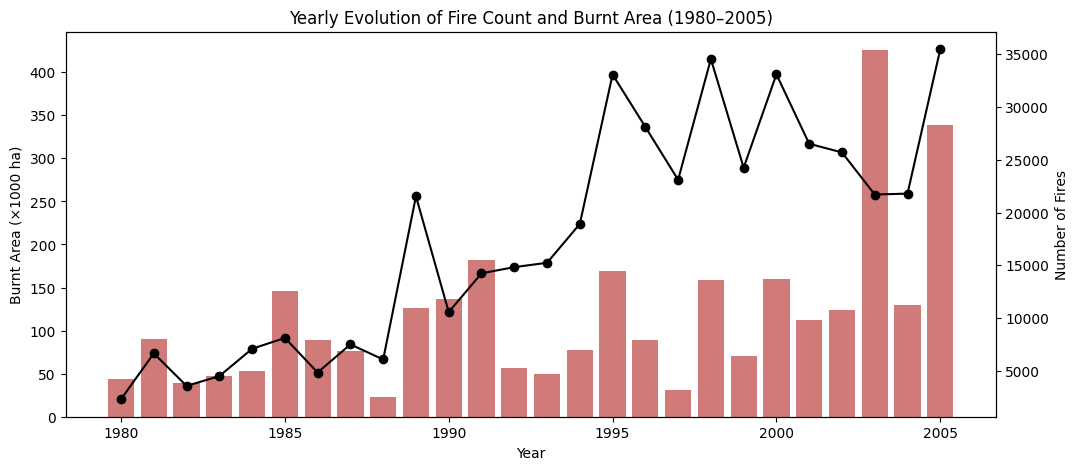

In [20]:
# Number of fires and total area per year
yearly = df.groupby('start_year').agg({'area_total': 'sum', 'district_id': 'count'}).rename(columns={'district_id': 'fire_count'})

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()

ax1.bar(yearly.index, yearly['area_total']/1000, color='firebrick', alpha=0.6, label='Total Burnt Area (×1000 ha)')
ax2.plot(yearly.index, yearly['fire_count'], color='black', marker='o', label='Number of Fires')

ax1.set_xlabel("Year")
ax1.set_ylabel("Burnt Area (×1000 ha)")
ax2.set_ylabel("Number of Fires")
ax1.set_title("Yearly Evolution of Fire Count and Burnt Area (1980–2005)")
plt.show()


The examination of the annual progression of rural fires from 1980 to 2005 indicates a definitive upward trajectory in both the frequency of recorded incidents and the aggregate area that has burned. The accompanying chart illustrates that the early years of the dataset, specifically the early 1980s, display comparatively low levels of fire activity, characterized by both limited frequency and a modest total area impacted. Nevertheless, beginning in the early 1990s, there is a significant escalation, characterized by frequent variances yet demonstrating a persistent overall augmentation in scale.
A few exceptional peaks are prominent in this time frame. The years **1995**, **1998**, and especially **2003** represent the very highest levels of destruction, with areas burned exceeding past records. These events overlap with very well-documented cases of extreme weather in Portugal, such as heat waves and dry periods that increased the spread of the fires. It is also significant that the link between frequency of fire and burned area is not a linear one — some years with comparably fewer ignitions represent much larger burned areas, implying that some specific fires had developed into large-scale, basin-scale events, rather than into multiple, smaller ones.

The results show a **slow increase in the number of rural-fire incidents** over the period between 1980 and 2005, consistent with the tendencies noted in the Portuguese Rural Fire Database (PRFD) documentation and also expressed by Pereira et al. (2011). This further confirms the need to consider both climatic variability and changes in land use as key factors leading towards increased intensity and frequency of wildfires in the mainland Portugal.

##### 2.3.2. Monthly Patterns  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

Fires show clear seasonality, peaking during the summer months.  
We will aggregate both fire counts and total burnt area by month.


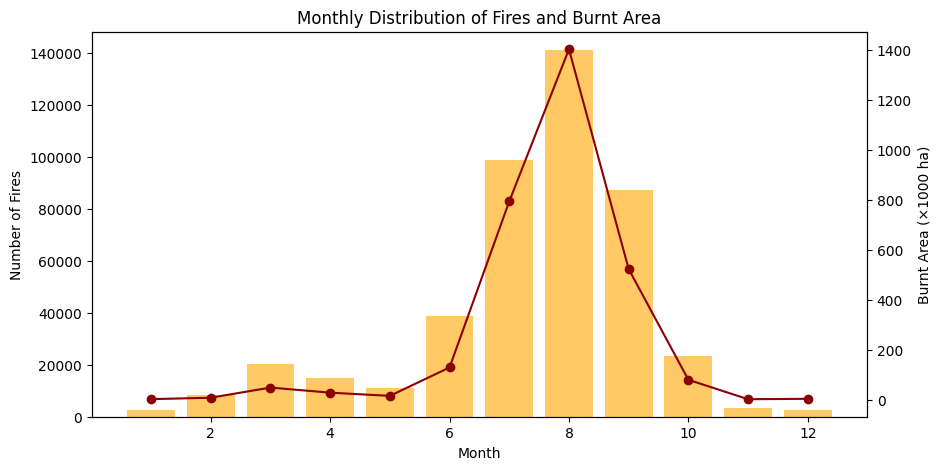

In [21]:
monthly = df.groupby('start_month').agg({'area_total':'sum','district_id':'count'}).rename(columns={'district_id':'fire_count'})
fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.bar(monthly.index, monthly['fire_count'], color='orange', alpha=0.6, label='Fire Count')
ax2.plot(monthly.index, monthly['area_total']/1000, color='darkred', marker='o', label='Total Area (×1000 ha)')

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Fires")
ax2.set_ylabel("Burnt Area (×1000 ha)")
ax1.set_title("Monthly Distribution of Fires and Burnt Area")
plt.show()


The monthly analysis of fire occurrences and total burnt area reveals a pronounced seasonal pattern. Fire activity remains very low during the colder and wetter months (from November to April), followed by a sharp and sustained increase throughout the summer season.  

From **June to September**, both the number of recorded fires and the corresponding burnt area rise dramatically, reaching a peak in **August**, when approximately one third of all fires in the dataset occur and the total burnt area reaches its annual maximum. This period coincides with the driest and hottest phase of the year in mainland Portugal, when vegetation is more flammable and atmospheric conditions strongly favor ignition and rapid propagation.  

After September, a marked decline is observed, returning to low levels by October and November. This seasonal distribution is consistent with the patterns described in the PRFD documentation and in national reports on wildfire activity, confirming the **strong dependence of rural fires on climatic and meteorological factors**. The dominance of summer months in both frequency and magnitude highlights the importance of preventive measures and early response systems during this critical season.


##### 2.3.3. Duration Distribution  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We now inspect how long fires last on average and how duration relates to burnt area.


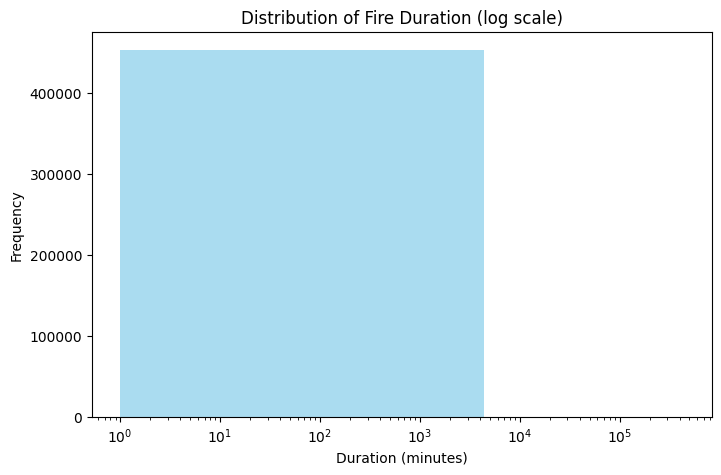

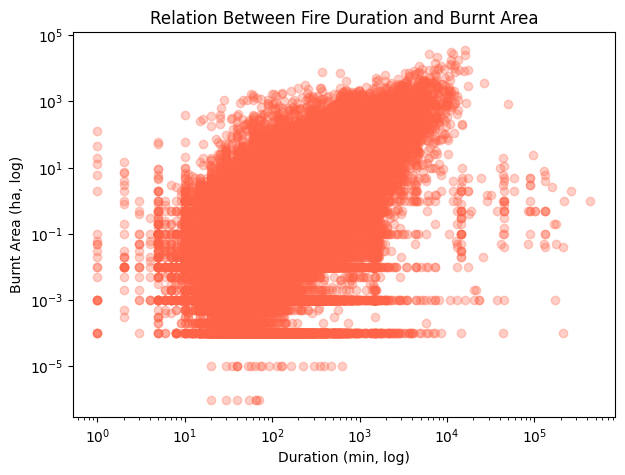

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['duration_min'], bins=100, color='skyblue', alpha=0.7)
plt.xscale('log')
plt.title("Distribution of Fire Duration (log scale)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

# Relation between duration and area
plt.figure(figsize=(7,5))
plt.scatter(df['duration_min'], df['area_total'], alpha=0.3, color='tomato')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Duration (min, log)")
plt.ylabel("Burnt Area (ha, log)")
plt.title("Relation Between Fire Duration and Burnt Area")
plt.show()



The first chart shows that most fires in the PRFD dataset lasted only a short time. Almost all events were controlled within a few hours, while only a small number extended for more than a day. This indicates that, in most situations, fire response was relatively fast or that the fires did not spread widely.  

In the second chart, we can see the relation between fire duration and total burnt area. There is a general trend showing that longer fires tend to burn larger areas. Still, there are some exceptions: a few short fires affected large areas, while some long ones remained small. These differences can be explained by local factors such as wind, vegetation type, or how quickly firefighting teams acted.  

Overall, the data suggests that **fire duration is related to the area burnt**, but other conditions strongly influence how much damage a fire can cause. Most extreme cases — very short but large fires, or very long but small ones — are rare and likely the result of unusual weather or terrain conditions.

##### 2.3.4. Spatial Analysis  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)


Understanding how fires are distributed spatially allows us to locate high-risk regions.  
Here we aggregate by district.


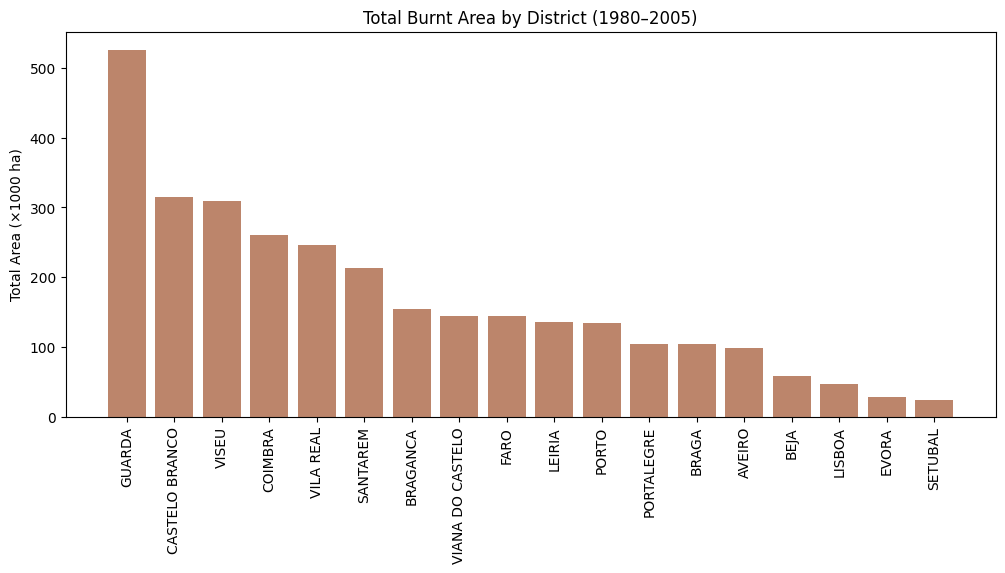

In [95]:
district_stats = df.groupby('district').agg({
    'area_total': 'sum',
    'district_id': 'count',
    'duration_min': 'mean'
}).rename(columns={'district_id':'fire_count'})

district_stats = district_stats.sort_values('area_total', ascending=False)

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(district_stats.index, district_stats['area_total']/1000, color='sienna', alpha=0.7)
plt.xticks(rotation=90)
plt.title("Total Burnt Area by District (1980–2005)")
plt.ylabel("Total Area (×1000 ha)")
plt.show()


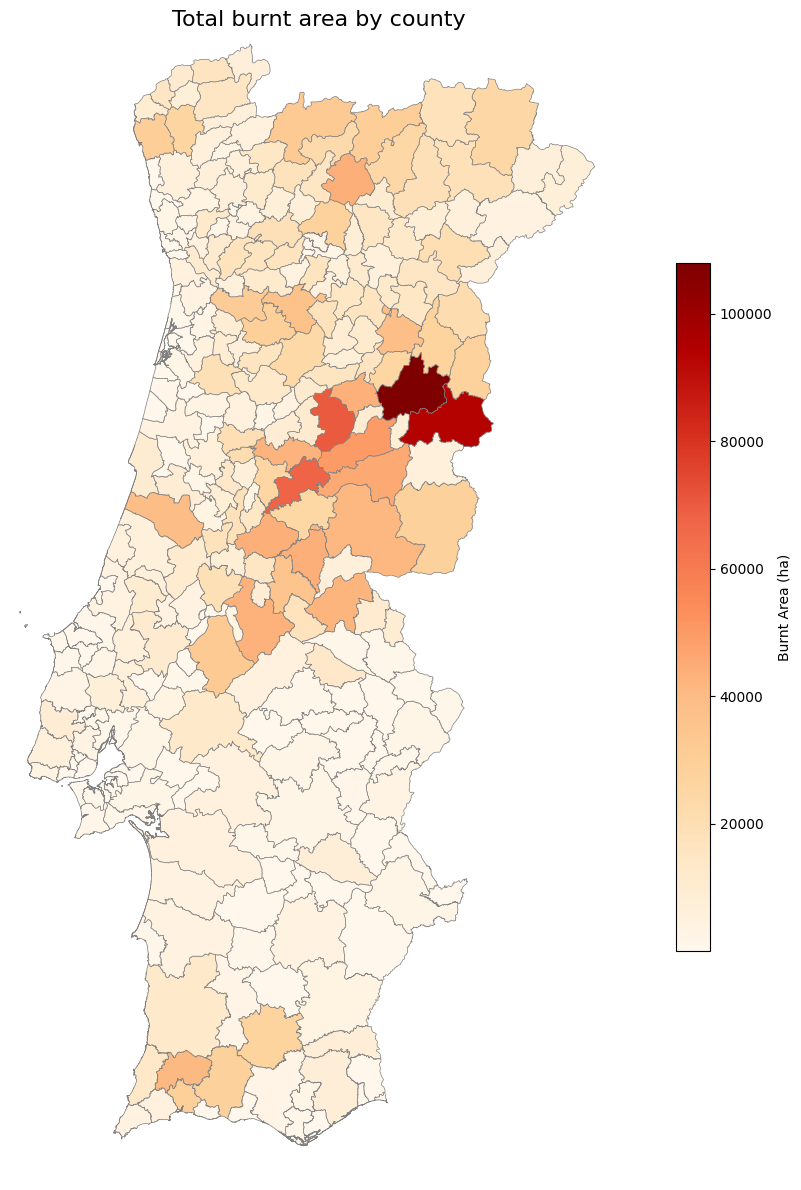

In [110]:
gdf= gpd.read_file("data/concelhos-shapefile/concelhos.shp")

county_stats = df.groupby('county').agg({
    'area_total': 'sum',
    'county': 'count',
    'duration_min': 'mean'
}).rename(columns={'county':'fire_count'}).reset_index()

def normalize_name(name):
    if pd.isna(name):
        return ""
    # Remove accents (e.g., ç -> c, ã -> a)
    name = ''.join(
        c for c in unicodedata.normalize('NFKD', name)
        if not unicodedata.combining(c)
    )
    # Replace dashes with spaces
    name = name.replace("-", " ")
    # Collapse multiple spaces and uppercase
    name = re.sub(r"\s+", " ", name).strip().upper()
    return name

gdf["NAME_2_norm"] = gdf["NAME_2"].apply(normalize_name) #this line makes every letter uppercase and substitutes ç for c and other special cases
county_stats["county_norm"] = county_stats["county"].apply(normalize_name)
merged = gdf.merge(county_stats, left_on="NAME_2_norm", right_on="county_norm", how="left")

#Plot

fig,ax= plt.subplots(1,1, figsize=(10,12))
merged.plot(
    column="area_total",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    legend_kwds={"shrink":0.6, "label": "Burnt Area (ha)"},
    ax=ax
)

ax.set_title("Total burnt area by county", fontsize=16)
ax.axis("off")

# limit the map to the continent 
ax.set_xlim([-9.6, -6.0])
ax.set_ylim([36.8, 42.2])

plt.tight_layout()
plt.show()

In [111]:
l1= gdf["NAME_2_norm"].unique()
l1.sort()
l2= county_stats['county_norm'].unique()
l2.sort()
print(f"Shape file county number: {len(l1)}")
print(f"Dataset county number: {len(l2)}")


for name in l2:
    if name not in l1:
        print(name)

Shape file county number: 304
Dataset county number: 279
GUIMARAES
TAVIRA
VILA POUCA


As we can se there are some counties that are **not repsented** in our data set or at least not by the same name as the shape file 
obtained in [dados.gov ](https://dados.gov.pt/en/datasets/concelhos-de-portugal/?utm_source=chatgpt.com#/resources) website

The spatial distribution of burnt area across Portuguese districts shows a clear regional pattern. The **central and northern interior regions** were the most affected by rural fires, with **Guarda**, **Castelo Branco**, and **Viseu** standing out as the districts with the largest total burnt area. These areas are characterized by extensive forest cover and rugged terrain, which favor both ignition and fire spread.

On the other hand, **coastal and southern districts** such as **Lisboa**, **Évora**, **Beja**, and **Setúbal** show much smaller values. This contrast reflects differences in vegetation density, land use, and climate conditions — particularly the drier but less forested nature of the Alentejo region and the higher urbanization along the coast.

Overall, the data reveals a strong **geographical asymmetry** in wildfire impact, confirming that central and northern inland districts play a major role in the country’s total burnt area during the 1980–2005 period.


##### 2.3.5. Spatial Distribution of Fire Incidents by District (1980–2005)
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The chart displays the spatial distribution of fire occurrences across Portuguese districts between 1980 and 2005.
Districts such as **Porto**, **Braga**, and **Viseu** register the highest number of incidents, indicating a strong concentration of fire activity in the northern region of the country.


/tmp/ipykernel_30390/2704917123.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fires_per_district = df.groupby('district')['district'].count().sort_values(ascending=False)


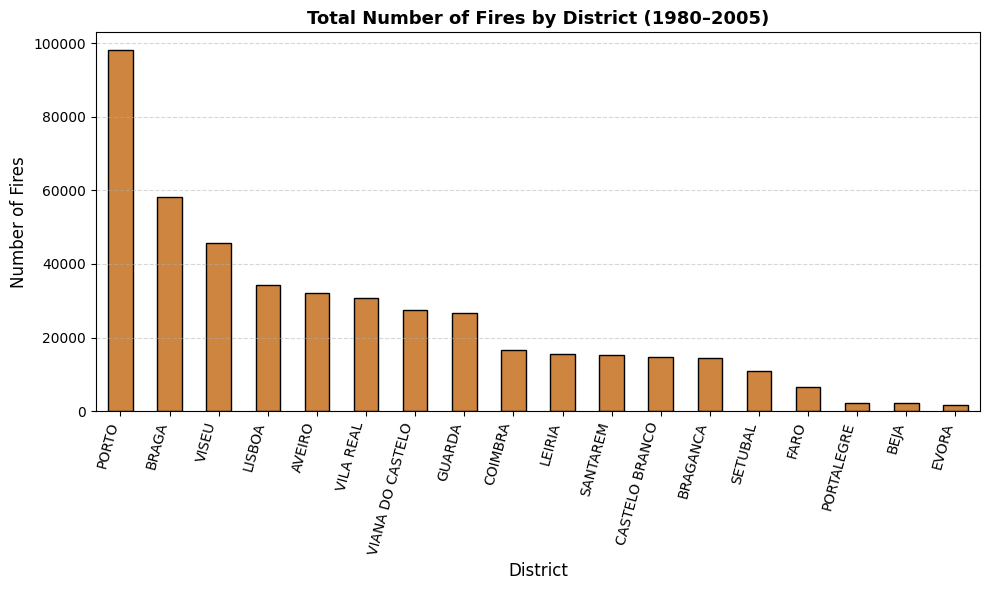

In [24]:
# --- Count number of fires per district ---
fires_per_district = df.groupby('district')['district'].count().sort_values(ascending=False)

# --- Plot ---
plt.figure(figsize=(10,6))
fires_per_district.plot(kind='bar', color='peru', edgecolor='black')

plt.title("Total Number of Fires by District (1980–2005)", fontsize=13, weight='bold')
plt.xlabel("District", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The data reveal a clear concentration of fire incidents in northern districts, particularly **Porto**, **Braga**, and **Viseu**.
However, this distribution appears disproportionate when compared with the actual extent of burned areas, since Porto does not possess large forested regions.
This suggests that in some districts, fires are more frequent but smaller in scale, whereas in others they may be fewer but cover larger areas, prompting the need for the next analysis to contrast **fire frequency** with **total area burned**.


##### 2.3.6. Comparison Between Fire Frequency and Total Burned Area by District (1980–2005)
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

This graph compares the **number of fires** (black line) and the **total burnt area** (brown bars) across Portuguese districts between 1980 and 2005.


/tmp/ipykernel_30390/888531461.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_stats = df.groupby('district').agg({


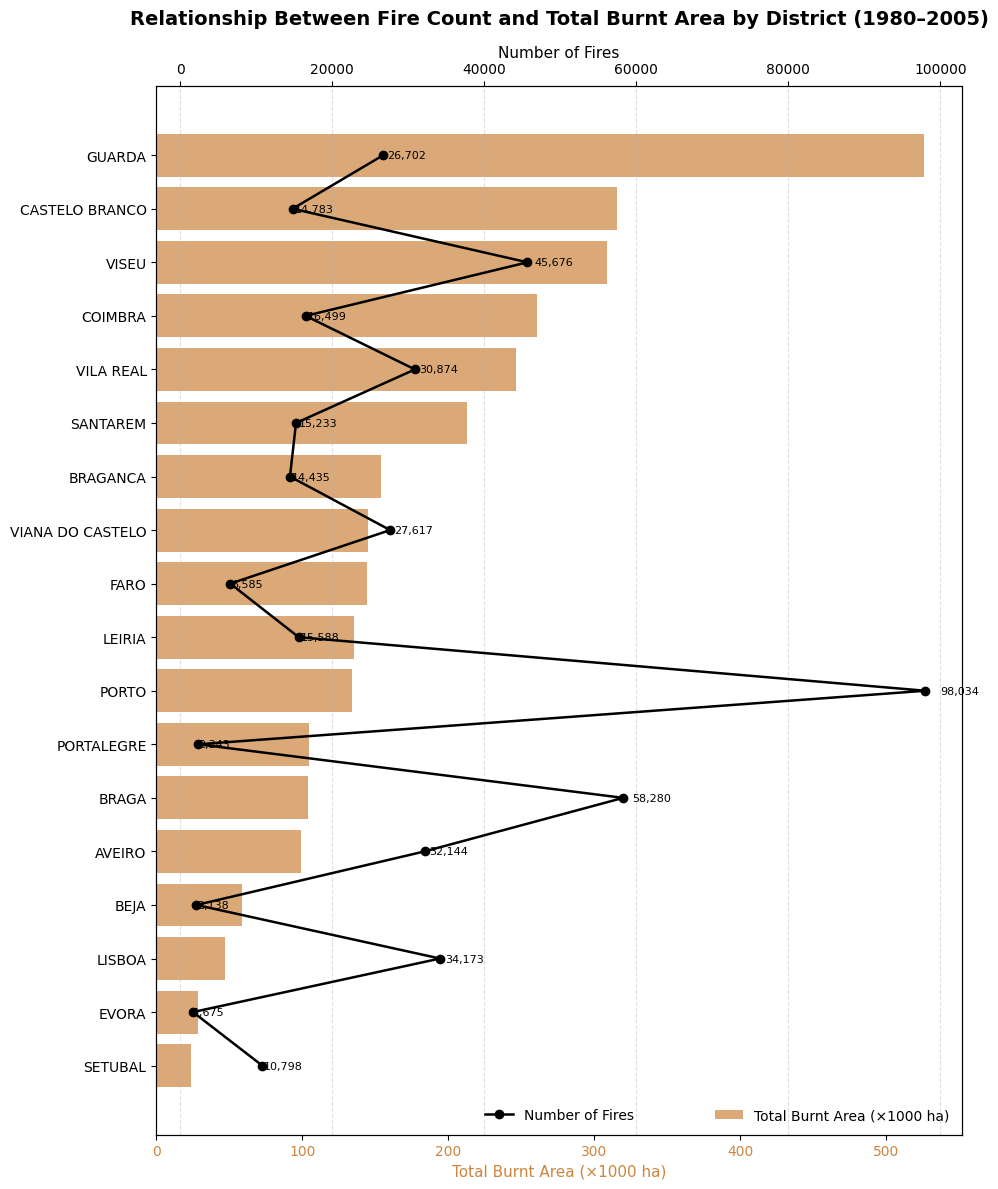

In [25]:
district_stats = df.groupby('district').agg({
    'area_total': 'sum',
    'district_id': 'count'
}).rename(columns={'district_id': 'fire_count'})

district_stats = district_stats.sort_values('area_total', ascending=True) # ascending order for horizontal bars

fig, ax1 = plt.subplots(figsize=(10, 12))

# --- Horizontal bars for total area ---
bars = ax1.barh(district_stats.index, district_stats['area_total'] / 1000,
                color='peru', alpha=0.7, label='Total Burnt Area (×1000 ha)')
ax1.set_xlabel("Total Burnt Area (×1000 ha)", color='peru', fontsize=11)
ax1.tick_params(axis='x', labelcolor='peru')

# --- Secondary axis for number of fires ---
ax2 = ax1.twiny()
ax2.plot(district_stats['fire_count'], district_stats.index,
         color='black', marker='o', linewidth=1.8, label='Number of Fires')
ax2.set_xlabel("Number of Fires", color='black', fontsize=11)
ax2.tick_params(axis='x', labelcolor='black')

# --- Fire Number Labels ---
for i, (fires, y) in enumerate(zip(district_stats['fire_count'], district_stats.index)):
    ax2.text(fires + fires * 0.02, i, f"{int(fires):,}", va='center',
             fontsize=8, color='black')

plt.title("Relationship Between Fire Count and Total Burnt Area by District (1980–2005)",
          fontsize=14, weight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.4)
ax1.legend(loc='lower right', frameon=False)
ax2.legend(loc='lower center', frameon=False)

plt.tight_layout()
plt.show()


The visualization clearly shows that northern and coastal districts, such as *Porto* and *Braga*, experienced the **highest number of fires**, but these were **generally smaller in area**.  
Conversely, central and interior regions, such as *Guarda*, *Castelo Branco*, and *Viseu*, had **fewer fires** but **significantly larger burnt areas**, indicating more severe events per ignition.

The horizontal labels improve readability, and the combined use of bars and lines helps illustrate the inverse relationship between frequency and intensity across regions.

##### 2.3.7. Land Cover Composition  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The PRFD distinguishes between burnt forest and shrubland areas.  
This helps identify which land-cover type is more vulnerable to fire.


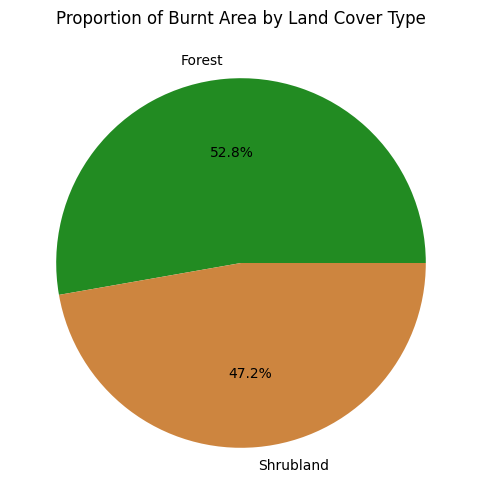

In [26]:
total_forest = df['forest_total'].sum()
total_shrub = df['shrub_total'].sum()

plt.figure(figsize=(6,6))
plt.pie([total_forest, total_shrub],
        labels=['Forest','Shrubland'],
        autopct='%1.1f%%',
        colors=['#228B22','#CD853F'])
plt.title("Proportion of Burnt Area by Land Cover Type")
plt.show()


The proportion of burnt area by land cover type reveals that **forest and shrubland areas were affected in almost equal measure** during the 1980–2005 period. Forests accounted for approximately **52.8%** of the total burnt area, while shrublands represented **47.2%**.  

This near balance suggests that fires in Portugal are not limited to a single vegetation type but rather affect both forested and shrub-dominated landscapes extensively. The slight predominance of forest fires reflects the large proportion of forested land in the central and northern regions, where conditions favor ignition and fire spread.  

In general, this distribution aligns with the structure of Portuguese rural landscapes, where forest and shrubland areas are often interspersed and both contribute significantly to the country’s wildfire statistics.

##### 2.3.8. Fire Size Categories  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

To better understand the distribution of fire magnitudes, we classify them into size categories.


/tmp/ipykernel_30390/1673599639.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_area = df.groupby('fire_size_cat')['area_total'].sum()


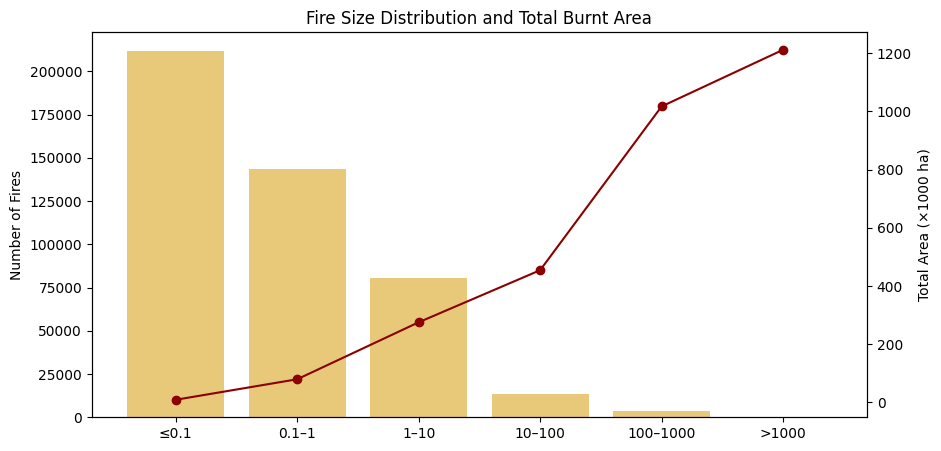

In [27]:
bins = [0, 0.1, 1, 10, 100, 1000, df['area_total'].max()]
labels = ['≤0.1','0.1–1','1–10','10–100','100–1000','>1000']
df['fire_size_cat'] = pd.cut(df['area_total'], bins=bins, labels=labels, include_lowest=True)

size_counts = df['fire_size_cat'].value_counts().sort_index()
size_area = df.groupby('fire_size_cat')['area_total'].sum()

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()
ax1.bar(size_counts.index, size_counts.values, alpha=0.6, label='Fire Count', color='goldenrod')
ax2.plot(size_area.index, size_area.values/1000, color='darkred', marker='o', label='Total Area (×1000 ha)')
ax1.set_ylabel("Number of Fires")
ax2.set_ylabel("Total Area (×1000 ha)")
plt.title("Fire Size Distribution and Total Burnt Area")
plt.show()


##### 2.3.9. Fire Causes  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

Understanding the distribution of causes is critical to identify human versus natural origins.

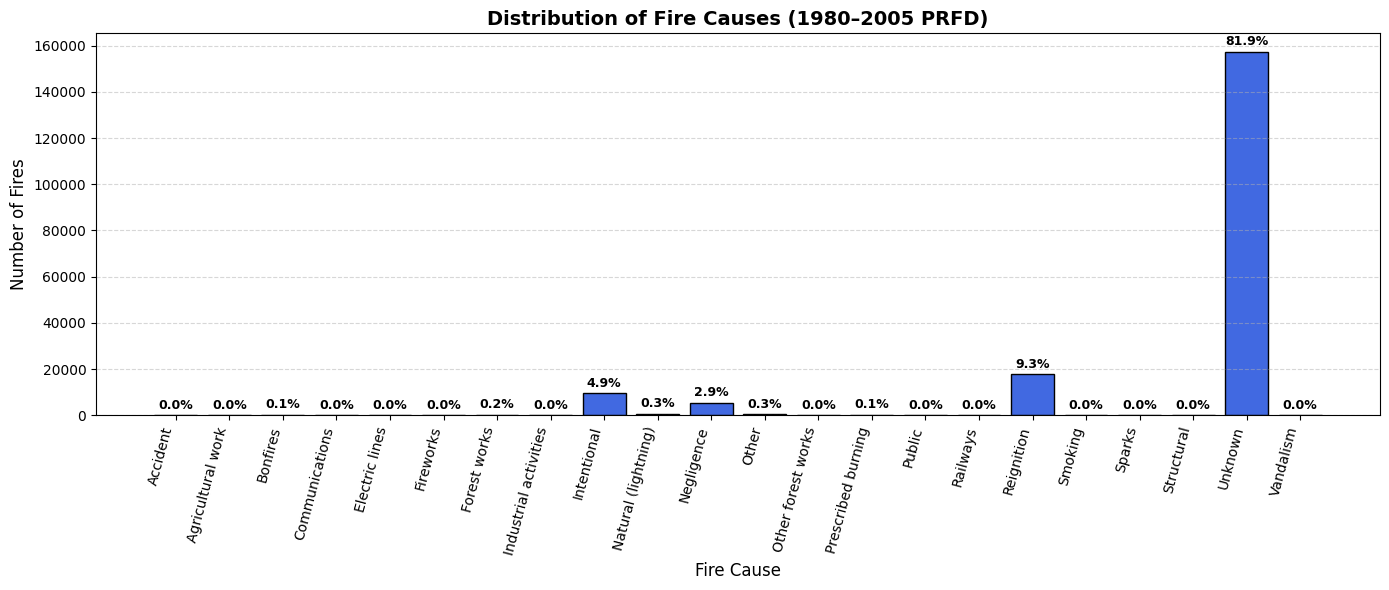

In [28]:
# --- Mapping from README (PRFD 2011) ---
cause_names = {
    1: "Negligence",
    2: "Prescribed burning",
    3: "Forest works",
    4: "Bonfires",
    5: "Smoking",
    6: "Sparks",
    7: "Railways",
    8: "Electric lines",
    9: "Fireworks",
    10: "Intentional",
    11: "Natural (lightning)",
    12: "Unknown",
    13: "Other",
    14: "Agricultural work",
    15: "Other forest works",
    16: "Industrial activities",
    17: "Communications",
    18: "Public",
    19: "Reignition",
    20: "Accident",
    21: "Structural",
    22: "Vandalism"
}

# --- Map numeric codes to names ---
df['cause_name'] = df['cause_code'].map(cause_names)

# --- Count occurrences ---
cause_counts = df['cause_name'].value_counts().sort_index()

# --- Calculate percentages ---
total_fires = cause_counts.sum()
percentages = (cause_counts / total_fires) * 100

# --- Plot ---
plt.figure(figsize=(14,6))
bars = plt.bar(cause_counts.index, cause_counts.values, color='royalblue', edgecolor='black')

# Title and labels
plt.title("Distribution of Fire Causes (1980–2005 PRFD)", fontsize=14, weight='bold')
plt.xlabel("Fire Cause", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01 * max(cause_counts.values)),
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


As shown in the previous figure, the category **“Unknown”** overwhelmingly dominates the distribution of fire causes,  
representing the vast majority of all recorded events.  

This occurs because, as documented in the official PRFD report (AFN, 2011) and in *Pereira et al. (2011)*,  
most fires (≈92.5%) were classified as *unknown cause* due to limited field investigation, particularly in the early decades of the dataset.  

To obtain a clearer picture of the **identified ignition sources**, the following analysis excludes the *“Unknown”* category.  
This allows for a more balanced comparison between the **human**, **natural**, and **reignition-related** causes actually recorded.

##### 2.3.10. Distribution of Fire Causes in Portugal (1980–2005, Excluding “Unknown”)
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

The plot highlights that intentional ignition and negligence account for the majority of recorded fires, together representing nearly 80% of known causes, underscoring the dominant role of human behavior in fire occurrence.

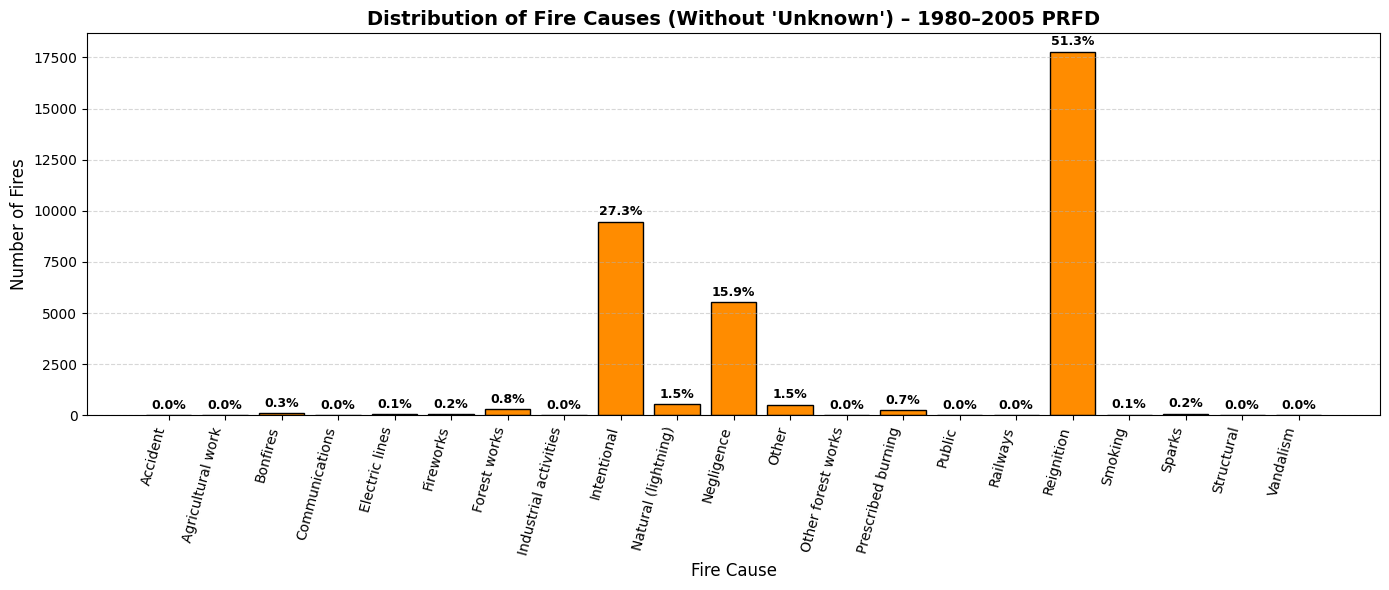

In [29]:
# Exclude "Unknown" to better visualize other causes
filtered_causes = cause_counts.drop("Unknown", errors="ignore")

# Calculate percentages
total_fires = filtered_causes.sum()
percentages = (filtered_causes / total_fires) * 100

# Plot
plt.figure(figsize=(14,6))
bars = plt.bar(filtered_causes.index, filtered_causes.values, color='darkorange', edgecolor='black')

# Title and labels
plt.title("Distribution of Fire Causes (Without 'Unknown') – 1980–2005 PRFD", fontsize=14, weight='bold')
plt.xlabel("Fire Cause", fontsize=12)
plt.ylabel("Number of Fires", fontsize=12)
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (0.01 * max(filtered_causes.values)),
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


##### 2.3.11. Correlation Matrix  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We inspect correlations among key numeric variables to detect interdependencies and potential predictive relationships.


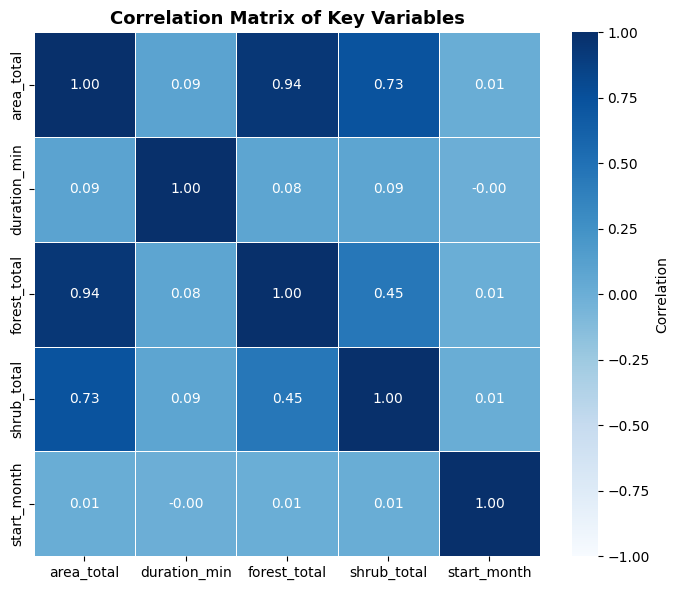

In [30]:
# Compute correlation matrix
corr = df[['area_total','duration_min','forest_total','shrub_total','start_month']].corr(numeric_only=True)

# Plot heatmap with blue color palette
plt.figure(figsize=(7,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',       # blue color scheme
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    fmt=".2f",          # two decimal places
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Matrix of Key Variables", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


The plot above represents a **correlation matrix**.  
Each cell quantifies the **Pearson correlation coefficient** between two numerical variables, ranging from -1 (perfect negative relationship) to +1 (perfect positive relationship).  
The diagonal values of **1.00** indicate that each variable is perfectly correlated with itself — this is expected and does **not** reflect relationships between different features.  

Notably, `area_total` shows a strong positive correlation with `forest_total` (0.94) and `shrub_total` (0.73), meaning larger fires tend to involve both forested and shrub-covered land.  
By contrast, `duration_min` and `start_month` display almost no correlation with the burned area, suggesting that fire size is not strongly dependent on duration or season alone.


##### 2.3.12. Derived Ratios  
[[go back to the topic]](#23-data-understanding-and-descriptive-analysis)

We can derive additional indicators such as the proportion of burnt forest vs shrub and the average spread rate (ha/h).


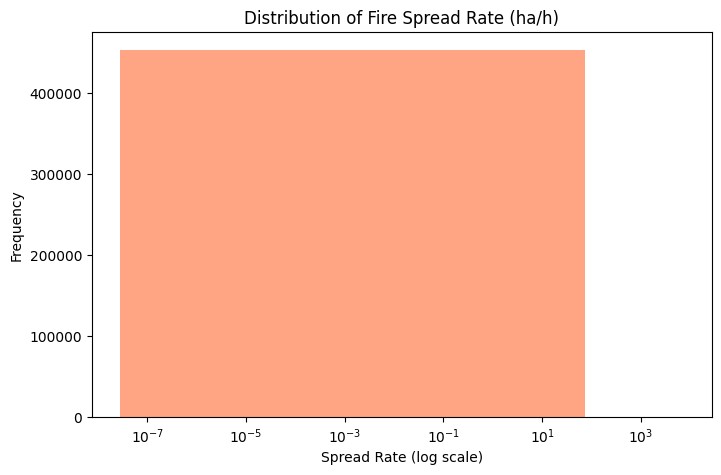

In [31]:
df['forest_ratio'] = df['forest_total'] / df['area_total'].replace(0, 1)
df['shrub_ratio'] = df['shrub_total'] / df['area_total'].replace(0, 1)
df['spread_rate'] = df['area_total'] / (df['duration_min'] / 60).replace(0, 1)

plt.figure(figsize=(8,5))
plt.hist(df['spread_rate'].dropna(), bins=100, color='coral', alpha=0.7)
plt.xscale('log')
plt.title("Distribution of Fire Spread Rate (ha/h)")
plt.xlabel("Spread Rate (log scale)")
plt.ylabel("Frequency")
plt.show()


The distribution of fire spread rate is highly skewed, with the majority of events concentrated at very low propagation values.
This indicates that most fires expand slowly, typically remaining localized, while a small minority exhibit extremely high spread rates.

Such imbalance is characteristic of wildfire data, where numerous small, quickly contained fires coexist with rare but severe large-scale events that dominate total burned area.


##### 2.3.13. Suspicious Records Visualization  
[[go back to the topic]](#2313-suspicious-records-visualization)

We highlight flagged records (those with extreme duration-area combinations) in the duration-area scatter plot.


Suspicious records: 348


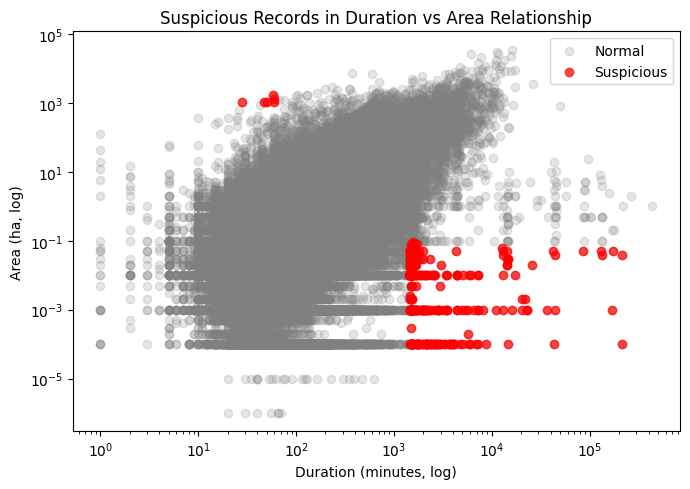

In [32]:
# --- Define suspicious fire conditions ---
tiny_long = (df['area_total'] < 0.1) & (df['duration_min'] > 1440)   # very small fires lasting > 1 day
huge_short = (df['area_total'] > 1000) & (df['duration_min'] < 60)   # huge fires lasting < 1 hour

# --- Create a new flag column ---
df['flag_suspicious'] = tiny_long | huge_short

# --- Check how many suspicious records exist ---
print("Suspicious records:", df['flag_suspicious'].sum())

# --- Plot relationship (log-log scale) ---
plt.figure(figsize=(7,5))
plt.scatter(df['duration_min'], df['area_total'], alpha=0.2, label='Normal', color='gray')
plt.scatter(df[df['flag_suspicious']]['duration_min'], df[df['flag_suspicious']]['area_total'],
            color='red', alpha=0.7, label='Suspicious')
plt.xscale('log'); plt.yscale('log')
plt.xlabel("Duration (minutes, log)")
plt.ylabel("Area (ha, log)")
plt.title("Suspicious Records in Duration vs Area Relationship")
plt.legend()
plt.tight_layout()
plt.show()


The script standardizes the dataset’s data types to ensure numerical and textual consistency.
Continuous variables such as areas, durations, and time fractions are coerced to **float**, while categorical or discrete identifiers like district IDs, fire type, and cause code are converted to **nullable integers (`Int64`)** to preserve missing values.
Geographic names and textual fields are stored as **strings**, ensuring a uniform schema and reliable handling of nulls before subsequent analysis or modelling.


In [33]:
# Save the cleaned and processed DataFrame
df.to_csv("data/FireDataset_clean.csv", index=False)


In [35]:
df = pd.read_csv("data/FireDataset_clean.csv")


/tmp/ipykernel_30390/556252358.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/FireDataset_clean.csv")
